In [20]:
import pandas as pd
import numpy as np
import os

# Adjust this to your actual path
DATA_DIR = '/Users/pallaviroysawant/projects/melanomaClassificationAML/siim-isic-melanoma-classification'

# Check the path is correct
print("Contents of DATA_DIR:")
for item in os.listdir(DATA_DIR):
    print(f"  {item}")

tfrecords_dir = os.path.join(DATA_DIR, "tfrecords")
print(" TFRECORDS DIR ")
for tffolder in ["test", "train"]:
    tffolder_path = os.path.join(DATA_DIR, tfrecords_dir)
    if os.path.exists(folder_path):
       n_image_tf = len([f for f in os.listdir(tffolder_path)])
       print(f"tfrecords/{tffolder}: {n_image_tf} images")

jpeg_dir = os.path.join(DATA_DIR, "jpeg")
print("JPEG DIR")
for folder in ["train", "test"]:
    folder_path = os.path.join(jpeg_dir, folder) 
    if os.path.exists(folder_path):
        n_images = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        print(f"  jpeg/{folder}: {n_images} images")
    else:
        print(f"  jpeg/{folder}: NOT FOUND")

dicom_dir = os.path.join(DATA_DIR, "dicom")
print(" DICOM DIR ")
for dicomfolder in ["test", "train"]:
    dicomfolder_path = os.path.join(dicom_dir, dicomfolder)
    if os.path.exists(folder_path):
       n_image_dicom = len([f for f in os.listdir(dicomfolder_path)])
       print(f"dicom_dir/{dicomfolder}: {n_image_dicom} images")

Contents of DATA_DIR:
  .DS_Store
  test.csv
  train.csv
  jpeg
  dicom
  tfrecords
  sample_submission.csv
 TFRECORDS DIR 
tfrecords/test: 32 images
tfrecords/train: 32 images
JPEG DIR
  jpeg/train: 33126 images
  jpeg/test: 10982 images
 DICOM DIR 
dicom_dir/test: 10982 images
dicom_dir/train: 33126 images


In [28]:
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(" F rows length ",len(df_train))
print(" F columns length ",len(df_train.columns))
print(" F columns ", list(df_train.columns))
print()
df_train.head(10)

 F rows length  33126
 F columns length  8
 F columns  ['image_name', 'patient_id', 'sex', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'benign_malignant', 'target']



,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0
5,ISIC_0074311,IP_2950485,female,40.0,lower extremity,unknown,benign,0
6,ISIC_0074542,IP_4698288,male,25.0,lower extremity,unknown,benign,0
7,ISIC_0075663,IP_6017204,female,35.0,torso,unknown,benign,0
8,ISIC_0075914,IP_7622888,male,30.0,torso,unknown,benign,0
9,ISIC_0076262,IP_5075533,female,50.0,lower extremity,unknown,benign,0


In [31]:
print("Target distribution:")
print(df_train['target'].value_counts())
print(f"\nMelanoma rate: {df_train['target'].mean()*100:.2f}%")

print("\n" + "="*50)

print("Beingn malignnent:")
print(df_train["benign_malignant"].value_counts())

print("\n" + "="*50)

print("Missing values per column:")
print(df_train.isnull().sum())


Target distribution:
target
0    32542
1      584
Name: count, dtype: int64

Melanoma rate: 1.76%

Beingn malignnent:
benign_malignant
benign       32542
malignant      584
Name: count, dtype: int64

Missing values per column:
image_name                         0
patient_id                         0
sex                               65
age_approx                        68
anatom_site_general_challenge    527
diagnosis                          0
benign_malignant                   0
target                             0
dtype: int64


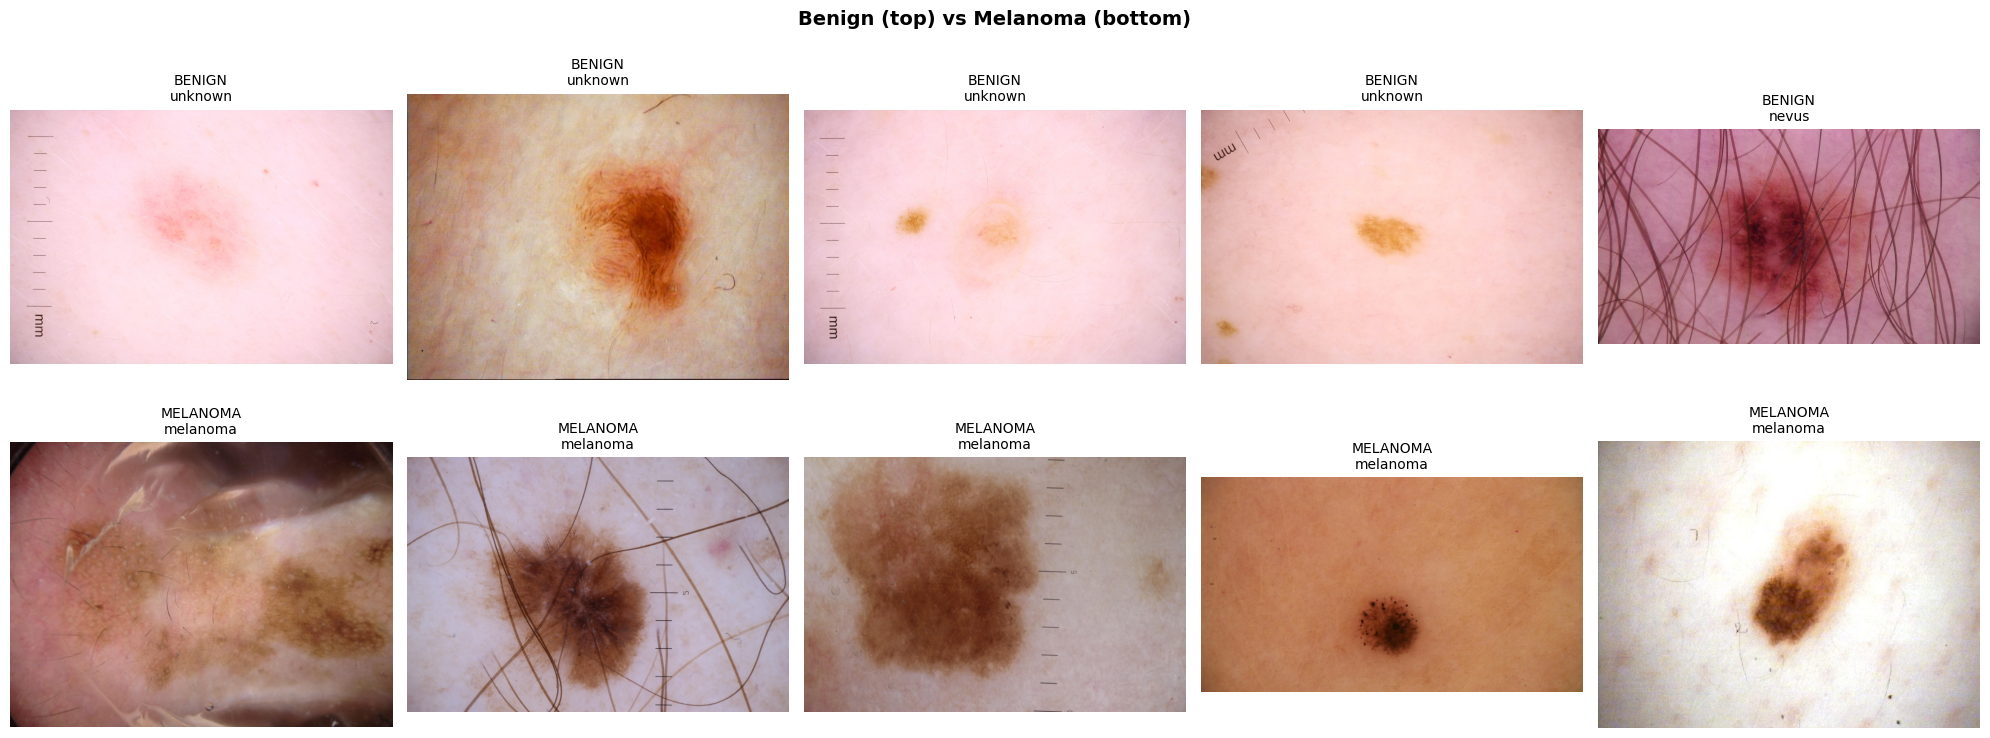

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

JPEG_DIR = os.path.join(DATA_DIR, 'jpeg', 'train')

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Benign samples
benign_samples = df_train[df_train['target'] == 0].sample(5, random_state=42)
for i, (_, row) in enumerate(benign_samples.iterrows()):
    img_path = os.path.join(JPEG_DIR, f"{row['image_name']}.jpg")
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"BENIGN\n{row['diagnosis']}", fontsize=10)
    axes[0, i].axis('off')

# Melanoma samples
melanoma_samples = df_train[df_train['target'] == 1].sample(5, random_state=42)
for i, (_, row) in enumerate(melanoma_samples.iterrows()):
    img_path = os.path.join(JPEG_DIR, f"{row['image_name']}.jpg")
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"MELANOMA\n{row['diagnosis']}", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Benign (top) vs Melanoma (bottom)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
from PIL import Image
import random

# taking 200 to begin with 
sample_images = df_train["image_name"].sample(200, random_state=42)

widths, heights = [], []
for name in sample_images:
    img_path = os.path.join(JPEG_DIR, f"{name}.jpg")
    img = Image.open(img_path) 
    widths.append(img.width)
    heights.append(img.height)

print(f"Image widths  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Image heights — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Unique sizes: {len(set(zip(widths, heights)))}")
    

Image widths  — min: 640, max: 6000, mean: 3872
Image heights — min: 480, max: 5184, mean: 2578
Unique sizes: 10
